### PySpark Otomoto Demo 

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023 


In [1]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


In [2]:
spark = SparkSession.builder \
    .appName("Otomoto Demo") \
    .getOrCreate()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/11 16:45:58 WARN Utils: Your hostname, Precision-5550, resolves to a loopback address: 127.0.1.1; using 192.168.0.110 instead (on interface enp58s0u2u4)
26/07/11 16:45:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/11 16:45:58 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [3]:

df = spark.read.option("header", True) \
    .option("delimiter", ";") \
    .option("inferSchema", False) \
    .csv("otomoto_offers_eng_23-04-2023.csv")


**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [4]:
df.show()

26/07/11 16:46:03 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+---------------+---------------+----------+-------------------+--------------+------+------------+-------------+---------------+---------------+---------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+----------------

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [5]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+-------------+---------------+----------+-------------------+---------+------+------------+-------------+---------------+---------------+--------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+-----------------+------

In [6]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

In [7]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|vehicle_brand|vehicle_model|price_num|mileage_km|production_year_int|engine_cc|power_hp|fuel_clean    |
+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|Volvo        |V70          |23200.0  |304000    |2010               |15603    |109     |diesel        |
|Honda        |Accord       |16800.0  |236000    |2005               |19983    |155     |gasoline      |
|Mercedes-Benz|Klasa X      |249900.0 |73000     |2019               |29873    |258     |diesel        |
|Toyota       |Avensis      |16499.0  |220000    |2005               |17943    |129     |gasoline      |
|Ford         |C-MAX        |29900.0  |179058    |2012               |19973    |140     |diesel        |
|Peugeot      |208          |80900.0  |1         |2023               |11993    |75      |gasoline      |
|Kia          |Sportage     |74770.0  |100420    |2018 

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [8]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

Średnia cena per marka


+-------------+----------+
|vehicle_brand|avg_price |
+-------------+----------+
|Lamborghini  |1281601.59|
|Ferrari      |1015648.41|
|McLaren      |866462.12 |
|Rolls-Royce  |762649.96 |
|Bentley      |657051.57 |
|Maybach      |575529.83 |
|Aston Martin |530891.29 |
|KTM          |389000.0  |
|Porsche      |363902.5  |
|Alpine       |352555.5  |
|RAM          |348905.66 |
|Geely        |346903.0  |
|BMW-ALPINA   |333006.94 |
|LEVC         |305776.0  |
|Skywell      |274743.33 |
|Maxus        |255052.59 |
|Tesla        |232544.92 |
|Caterham     |227550.0  |
|Land Rover   |200495.64 |
|Maserati     |197591.6  |
+-------------+----------+
only showing top 20 rows


In [9]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [10]:
df.createOrReplaceTempView("cars")

In [11]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      McLaren|    652.5|38811.5| 866462.1|
|  Lamborghini|    637.8|51767.4|1281601.6|
|      Ferrari|    632.9|46168.3|1015648.4|
|      Bentley|    550.8|54644.1| 657051.6|
|      Maybach|    541.0|53499.7| 575529.8|
| Aston Martin|    528.1|48457.7| 530891.3|
|   BMW-ALPINA|    516.0|40259.4| 333006.9|
|        Tesla|    486.4| 6023.0| 232544.9|
|  Rolls-Royce|    479.7|65997.4| 762650.0|
|          RAM|    413.2|55898.3| 348905.7|
|     Polestar|    408.0|   NULL| 146750.0|
|     Maserati|    397.7|31911.3| 197591.6|
|      Porsche|    376.8|33072.8| 363902.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    341.5|46547.9| 142202.8|
|      Genesis|    336.3|31915.5| 108725.0|
|     Cadillac|    309.1|47372.8| 140824.6|
|          GMC|    290.3|50369.8| 135253.3|
|     Plymouth|    287.5|50298.0| 125230.0|
|       Hummer|    278.3|49413.6

In [12]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("production_year_int").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2023|12987|
|               2022|13680|
|               2021| 7729|
|               2020| 7787|
|               2019|13978|
|               2018|15096|
|               2017|13952|
|               2016|11755|
|               2015|10640|
|               2014| 9988|
|               2013| 9341|
|               2012| 9664|
|               2011|10108|
|               2010| 9115|
|               2009| 9040|
|               2008| 8846|
|               2007| 7816|
|               2006| 6320|
|               2005| 5121|
|               2004| 3647|
+-------------------+-----+
only showing top 20 rows


In [13]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Mercedes-Benz|SLR          |2340000.0 |2380.0     |
|Ferrari      |SF90 Stradale|2293626.0 |1855.75    |
|Rolls-Royce  |Dawn         |1999999.0 |4300.0     |
|Lamborghini  |Aventador    |1822661.67|14467.5    |
|Ferrari      |812 Superfast|1670200.0 |16414.0    |
|Lamborghini  |Murcielago   |1550000.0 |46950.0    |
|McLaren      |Artura       |1499000.0 |2100.0     |
|McLaren      |675Lt        |1290000.0 |18500.0    |
|McLaren      |600lt-coupe  |1289000.0 |8500.0     |
|Lamborghini  |Huracan      |1258737.0 |25671.46   |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Rolls-Royce  |Ghost        |1206316.67|39451.67   |
|Bentley      |Bentayga     |1200222.11|34022.72   |
|Lamborghini  |Diablo       |1199900.0 |32164.0    |
|Rolls-Royce  |Wraith       |1183000.0 |54333.

In [14]:
# zależność ceny od przebiegu 
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


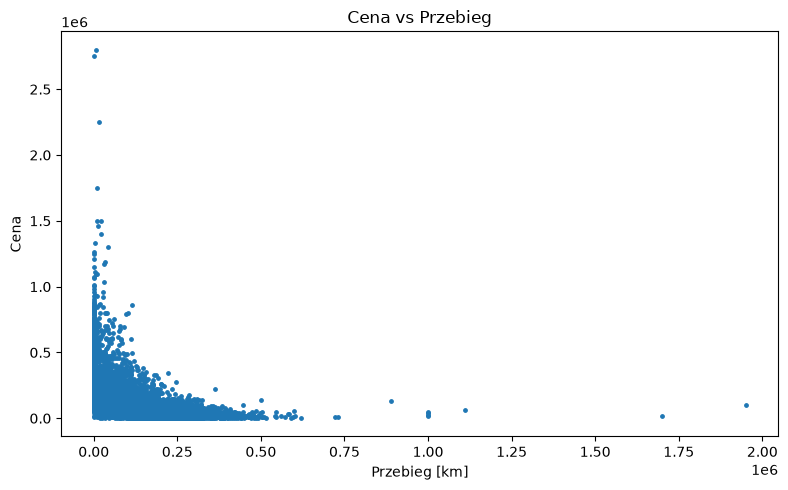

In [15]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6)
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [16]:
# Tutaj wpisz swój kod zliczający, czytający plik itp.
# Podpowiedź krok 1:
# df_crimes = spark.read.option("header", True).csv("chicago_crimes_sample.csv")
# df_crimes.show(5)



In [17]:
from pyspark.sql import functions as F, types as T
from pyspark.sql.window import Window


INPUT_PATH = "chicago_crimes_sample.csv"
OUTPUT_PATH = "output/chicago_crimes_parquet"

In [18]:
crimes = (
    spark.read
    .option("header", True)
    .option("multiLine", True)
    .option("escape", '"')
    .csv(INPUT_PATH)
    .dropDuplicates(["id"])
    .withColumn("date", F.to_timestamp("date", "yyyy-MM-dd'T'HH:mm:ss.SSS"))
    .withColumn("arrest", F.col("arrest").cast("boolean"))
    .withColumn("domestic", F.col("domestic").cast("boolean"))
    .dropna(subset=["id", "date", "primary_type", "location_description"])
    .filter(F.col("date") <= F.current_timestamp())
    .withColumn("year", F.year("date"))
    .withColumn("hour", F.hour("date"))
)

In [19]:
@F.udf(T.StringType())
def classify_time(hour):
    if hour is None:
        return None
    if hour < 6:
        return "night"
    if hour < 12:
        return "morning"
    if hour < 18:
        return "afternoon"
    return "evening"


crimes = crimes.withColumn("time_of_day", classify_time("hour"))


time_dictionary = spark.createDataFrame(
    [
        ("night", 1),
        ("morning", 2),
        ("afternoon", 3),
        ("evening", 4),
    ],
    ["time_of_day", "time_order"],
)

crimes = (
    crimes.join(F.broadcast(time_dictionary), "time_of_day", "left")
    .cache()
)

print(f"Clean records: {crimes.count():,}")

Clean records: 49,803


In [20]:
top_crimes = (
    crimes.groupBy("primary_type")
    .agg(
        F.count("*").alias("crime_count"),
        F.round(F.avg(F.col("arrest").cast("int")) * 100, 2)
        .alias("arrest_rate_pct"),
    )
    .orderBy(F.desc("crime_count"))
)

top_crimes.show(15, truncate=False)

+--------------------------+-----------+---------------+
|primary_type              |crime_count|arrest_rate_pct|
+--------------------------+-----------+---------------+
|THEFT                     |10920      |9.09           |
|BATTERY                   |9253       |18.03          |
|CRIMINAL DAMAGE           |5497       |4.6            |
|ASSAULT                   |4564       |12.84          |
|MOTOR VEHICLE THEFT       |3886       |3.86           |
|OTHER OFFENSE             |3459       |15.29          |
|BURGLARY                  |3163       |2.69           |
|DECEPTIVE PRACTICE        |2486       |2.41           |
|NARCOTICS                 |1455       |93.06          |
|CRIMINAL TRESPASS         |1193       |34.45          |
|WEAPONS VIOLATION         |1022       |73.78          |
|ROBBERY                   |916        |6.33           |
|OFFENSE INVOLVING CHILDREN|368        |7.07           |
|CRIMINAL SEXUAL ASSAULT   |331        |1.21           |
|SEX OFFENSE               |306

In [21]:
location_analysis = (
    crimes.groupBy(
        "location_description",
        "time_order",
        "time_of_day",
        "primary_type",
    )
    .count()
)

In [22]:
location_analysis.explain("formatted")


== Physical Plan ==
AdaptiveSparkPlan (37)
+- HashAggregate (36)
   +- Exchange (35)
      +- HashAggregate (34)
         +- InMemoryTableScan (1)
               +- InMemoryRelation (2)
                     +- AdaptiveSparkPlan (33)
                        +- == Final Plan ==
                           ResultQueryStage (20)
                           +- * Project (19)
                              +- * BroadcastHashJoin LeftOuter BuildRight (18)
                                 :- * Project (13)
                                 :  +- BatchEvalPython (12)
                                 :     +- * Project (11)
                                 :        +- * Filter (10)
                                 :           +- SortAggregate (9)
                                 :              +- * Sort (8)
                                 :                 +- ShuffleQueryStage (7), Statistics(sizeInBytes=29.8 MiB, rowCount=5.00E+4)
                                 :                    +- Exchange (

In [23]:
ranking = Window.partitionBy(
    "location_description",
    "time_of_day",
).orderBy(
    F.desc("count"),
    F.asc("primary_type"),
)

(
    location_analysis
    .withColumn("rank", F.row_number().over(ranking))
    .filter(F.col("rank") <= 3)
    .orderBy("location_description", "time_order", "rank")
    .show(100, truncate=False)
)


+-----------------------------------------------+----------+-----------+---------------------------------+-----+----+
|location_description                           |time_order|time_of_day|primary_type                     |count|rank|
+-----------------------------------------------+----------+-----------+---------------------------------+-----+----+
|ABANDONED BUILDING                             |1         |night      |CRIMINAL DAMAGE                  |1    |1   |
|ABANDONED BUILDING                             |1         |night      |DECEPTIVE PRACTICE               |1    |2   |
|ABANDONED BUILDING                             |2         |morning    |ASSAULT                          |1    |1   |
|ABANDONED BUILDING                             |2         |morning    |BURGLARY                         |1    |2   |
|ABANDONED BUILDING                             |2         |morning    |CRIMINAL DAMAGE                  |1    |3   |
|ABANDONED BUILDING                             |3      

In [24]:
(
    crimes.write
    .mode("overwrite")
    .partitionBy("year")
    .parquet(OUTPUT_PATH)
)


26/07/11 16:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/07/11 16:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/07/11 16:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/07/11 16:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/07/11 16:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/07/11 16:46:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/07/11 16:46:23 WARN MemoryManager: Total allocation exceeds 95.

In [25]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import (
    IndexToString,
    OneHotEncoder,
    StringIndexer,
    VectorAssembler,
)


ml_data = (
    crimes.select(
        "primary_type",
        "location_description",
        "time_of_day",
        "hour",
        F.col("arrest").cast("double").alias("arrest"),
        F.col("domestic").cast("double").alias("domestic"),
    )
    .dropna()
)

train_data, test_data = ml_data.randomSplit([0.8, 0.2], seed=0)

In [26]:
label_indexer = StringIndexer(
    inputCol="primary_type",
    outputCol="label",
    handleInvalid="keep",
)

location_indexer = StringIndexer(
    inputCol="location_description",
    outputCol="location_index",
    handleInvalid="keep",
)

time_indexer = StringIndexer(
    inputCol="time_of_day",
    outputCol="time_index",
    handleInvalid="keep",
)

encoder = OneHotEncoder(
    inputCols=["location_index", "time_index"],
    outputCols=["location_vector", "time_vector"],
)

assembler = VectorAssembler(
    inputCols=[
        "location_vector",
        "time_vector",
        "hour",
        "arrest",
        "domestic",
    ],
    outputCol="features",
)

classifier = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=30,
    maxDepth=8,
    seed=0,
)

In [27]:
pipeline = Pipeline(
    stages=[
        label_indexer,
        location_indexer,
        time_indexer,
        encoder,
        assembler,
        classifier,
    ]
)

model = pipeline.fit(train_data)
predictions = model.transform(test_data)

In [28]:
accuracy = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy",
).evaluate(predictions)

weighted_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedFMeasure",
).evaluate(predictions)

decoded_predictions = IndexToString(
    inputCol="prediction",
    outputCol="predicted_type",
    labels=model.stages[0].labels,
).transform(predictions)

print(f"Accuracy:    {accuracy:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

Accuracy:    0.310
Weighted F1: 0.183


In [29]:
decoded_predictions.select(
    "primary_type",
    "predicted_type",
    "location_description",
    "time_of_day",
    "hour",
).show(20, truncate=False)

+---------------+--------------+------------------------+-----------+----+
|primary_type   |predicted_type|location_description    |time_of_day|hour|
+---------------+--------------+------------------------+-----------+----+
|ASSAULT        |THEFT         |RESIDENCE               |evening    |18  |
|ASSAULT        |BATTERY       |RESIDENCE               |evening    |22  |
|ASSAULT        |THEFT         |STREET                  |morning    |9   |
|ASSAULT        |THEFT         |STREET                  |morning    |10  |
|BATTERY        |THEFT         |ALLEY                   |evening    |23  |
|BATTERY        |BATTERY       |APARTMENT               |evening    |18  |
|BATTERY        |BATTERY       |APARTMENT               |evening    |19  |
|BATTERY        |BATTERY       |APARTMENT               |evening    |20  |
|BATTERY        |BATTERY       |APARTMENT               |night      |3   |
|BATTERY        |BATTERY       |CHA APARTMENT           |evening    |23  |
|BATTERY        |BATTERY 

In [30]:
class_distribution = (
    test_data.groupBy("primary_type")
    .count()
    .orderBy(F.desc("count"))
)

class_distribution.show(20, truncate=False)

total = test_data.count()
largest_class = class_distribution.first()["count"]

print(f"Majority-class baseline: {largest_class / total:.3f}")

+--------------------------------+-----+
|primary_type                    |count|
+--------------------------------+-----+
|THEFT                           |2172 |
|BATTERY                         |1888 |
|CRIMINAL DAMAGE                 |1146 |
|ASSAULT                         |904  |
|MOTOR VEHICLE THEFT             |786  |
|OTHER OFFENSE                   |723  |
|BURGLARY                        |639  |
|DECEPTIVE PRACTICE              |493  |
|NARCOTICS                       |295  |
|CRIMINAL TRESPASS               |222  |
|WEAPONS VIOLATION               |190  |
|ROBBERY                         |186  |
|OFFENSE INVOLVING CHILDREN      |79   |
|CRIMINAL SEXUAL ASSAULT         |76   |
|SEX OFFENSE                     |65   |
|PUBLIC PEACE VIOLATION          |46   |
|INTERFERENCE WITH PUBLIC OFFICER|37   |
|STALKING                        |30   |
|ARSON                           |16   |
|HOMICIDE                        |15   |
+--------------------------------+-----+
only showing top

In [31]:
(
    decoded_predictions.groupBy("predicted_type")
    .count()
    .orderBy(F.desc("count"))
    .show(20, truncate=False)
)

+--------------+-----+
|predicted_type|count|
+--------------+-----+
|THEFT         |7245 |
|BATTERY       |2807 |
+--------------+-----+



In [32]:
accuracy_gain = accuracy - largest_class / total

print(f"Accuracy:          {accuracy:.3f}")
print(f"Baseline:          {largest_class / total:.3f}")
print(f"Improvement:       {accuracy_gain:.3f}")
print(f"Weighted F1 score: {weighted_f1:.3f}")

Accuracy:          0.310
Baseline:          0.216
Improvement:       0.094
Weighted F1 score: 0.183


In [33]:
crimes.unpersist()

DataFrame[time_of_day: string, id: string, case_number: string, date: timestamp, block: string, iucr: string, primary_type: string, description: string, location_description: string, arrest: boolean, domestic: boolean, beat: string, district: string, ward: string, community_area: string, fbi_code: string, x_coordinate: string, y_coordinate: string, year: int, updated_on: string, latitude: string, longitude: string, location: string, hour: int, time_order: bigint]